In [ ]:
# 1. Install Unsloth
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# 2. Install dependencies WITHOUT the xformers version limit!
!pip install -q --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 146.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 112.0 MB/s 

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"

# Configure 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load the Model across both T4 GPUs
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

# Prepare for training and inject LoRA Adapters
model = prepare_model_for_kbit_training(model)
peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:259: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
!pip install -q -U bitsandbytes peft trl accelerate transformers datasets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.3.7 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.4 which is incompatible.
unsloth-zoo 2026.3.7 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.3.0,>=4.51.3, but you have transformers 5.4.0 which is incompatible.
unsloth-zoo 2026.3.7 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 1.0.0 which is incompatible.


In [ ]:
from datasets import load_dataset

# IMPORTANT: Replace these paths with your actual Kaggle dataset paths!
# You can find the exact paths by exploring the 'Input' folder on the right panel in Kaggle.
data_files = {
    "train": "/content/drive/MyDrive/DATASET/train.csv",
    "validation": "/content/drive/MyDrive/DATASET/val.csv",
    "test": "/content/drive/MyDrive/DATASET/test.csv"
}

# Load the dataset splits
dataset = load_dataset("csv", data_files=data_files)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
prompt_template = """You are an expert at analyzing Bengali social media text to detect hate speech.
Analyze the following Bengali text and extract three specific attributes.

Return your analysis STRICTLY in the following JSON format without any additional text:
{{
  "hate_presence": "Hate Speech" or "Not Hate Speech",
  "hate_type": "Call to Violence", "Slander", "Religious Hate", or "Not Specified",
  "target_category": "Individual", "Male", "Female", "Group", or "Not Specified"
}}

### Input Text:
{text}

### Response:
{response}"""

def format_dataset(example):
    # 1. Map the binary integer label to a clear string
    presence = "Hate Speech" if str(example["hate_presence"]) == "1" else "Not Hate Speech"

    # 2. Extract Type and Target. Using .get() ensures it won't crash if a row is missing data
    h_type = str(example.get("hate_type", "Not Specified"))
    target = str(example.get("target_category", "Not Specified"))

    # Logical override: If it's not hate speech, the type and target MUST be "Not Specified"
    if presence == "Not Hate Speech":
        h_type = "Not Specified"
        target = "Not Specified"

    # 3. Construct the expected JSON output
    expected_json = f'{{\n  "hate_presence": "{presence}",\n  "hate_type": "{h_type}",\n  "target_category": "{target}"\n}}'

    # 4. Combine into the final prompt and append the model's specific End-Of-Sequence token
    full_prompt = prompt_template.format(text=example["text"], response=expected_json) + tokenizer.eos_token

    return {"formatted_prompt": full_prompt}

In [ ]:
def format_dataset(example):
    # 1. Map to your exact column names from the CSV image
    input_text = example["sentence"]
    binary_label = example["hate speech"]

    # 2. Map the binary integer label to a clear string
    presence = "Hate Speech" if str(binary_label) == "1" else "Not Hate Speech"

    # 3. Extract Type and Target using the correct headers
    h_type = str(example.get("type", "Not Specified"))   # <-- Updated to "type"
    target = str(example.get("target", "Not Specified")) # <-- Matches "target"

    # Logical override: If it's not hate speech, the type and target MUST be "Not Specified"
    if presence == "Not Hate Speech":
        h_type = "Not Specified"
        target = "Not Specified"

    # 4. Construct the expected JSON output
    expected_json = f'{{\n  "hate_presence": "{presence}",\n  "hate_type": "{h_type}",\n  "target_category": "{target}"\n}}'

    # 5. Combine into the final prompt
    full_prompt = prompt_template.format(text=input_text, response=expected_json) + tokenizer.eos_token

    return {"formatted_prompt": full_prompt}

# Now try the mapping again!
formatted_dataset = dataset.map(format_dataset)
print(formatted_dataset["train"][0]["formatted_prompt"])

Map:   0%|          | 0/40224 [00:00<?, ? examples/s]

Map:   0%|          | 0/5028 [00:00<?, ? examples/s]

Map:   0%|          | 0/5029 [00:00<?, ? examples/s]

You are an expert at analyzing Bengali social media text to detect hate speech.
Analyze the following Bengali text and extract three specific attributes.

Return your analysis STRICTLY in the following JSON format without any additional text:
{
  "hate_presence": "Hate Speech" or "Not Hate Speech",
  "hate_type": "Call to Violence", "Slander", "Religious Hate", or "Not Specified",
  "target_category": "Individual", "Male", "Female", "Group", or "Not Specified"
}

### Input Text:
.... ঐ ইন্দুর তোই মরছ নাই?

### Response:
{
  "hate_presence": "Hate Speech",
  "hate_type": "callToViolence",
  "target_category": "ind"
}<|eot_id|>


In [ ]:
!pip install -q -U transformers accelerate

In [ ]:
# Not Necessary
from transformers import TrainingArguments

# Set up the hyperparameter configurations
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,      # Small physical batch size to fit in VRAM
    gradient_accumulation_steps=4,      # 2 (batch) x 4 (accumulation) = 8 effective batch size
    learning_rate=2e-4,                 # Keeping your proven learning rate
    logging_steps=10,
    max_steps=100,                      # ⚠️ FOR TESTING: We will only run 100 steps first!
    # num_train_epochs=1,               # Uncomment this later for the full training run
    save_strategy="steps",
    save_steps=50,
    eval_strategy="steps",              # <-- CHANGED THIS LINE
    eval_steps=50,
    optim="paged_adamw_8bit",           # Crucial memory-saving optimizer
    fp16=True,                          # T4 GPUs use fp16, not bf16
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
)

In [ ]:
!pip install -q -U trl peft accelerate bitsandbytes

In [ ]:
!pip install -q -U trl

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.3.6 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.4 which is incompatible.
unsloth-zoo 2026.3.6 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 1.0.0 which is incompatible.


In [ ]:
!pip install -q -U transformers trl

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.3.6 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.4 which is incompatible.
unsloth-zoo 2026.3.6 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.3.0,>=4.51.3, but you have transformers 5.4.0 which is incompatible.
unsloth-zoo 2026.3.6 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 1.0.0 which is incompatible.


In [ ]:
# Strip out the conflicting new versions
!pip uninstall -y transformers trl

# Install the exact stable versions that Unsloth requires
!pip install -q transformers==4.43.4 trl==0.8.6

Found existing installation: transformers 5.4.0
Uninstalling transformers-5.4.0:
  Successfully uninstalled transformers-5.4.0
Found existing installation: trl 1.0.0
Uninstalling trl-1.0.0:
  Successfully uninstalled trl-1.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 68.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.3.7 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.8.4 which is incompatible.
unsloth-zoo 2026.3.7 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.3.0,>=4.51

In [ ]:
# Install Unsloth
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# Install everything else WITHOUT version locks so they sync perfectly
!pip install -q --no-deps xformers trl peft accelerate bitsandbytes transformers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.7 MB/s eta 0:00:00


In [ ]:
from trl import SFTTrainer

# Initialize the trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["validation"],
    dataset_text_field="formatted_prompt", # The column we created in Phase 2
    max_seq_length=2048,                   # Matches your initial setup
    args=training_args,
    packing=False,                         # Keep false for structured JSON output
)

NameError: name 'model' is not defined

In [ ]:
!pip install -q transformers==5.3.0 trl==0.24.0 datasets==4.3.0

In [ ]:
import os
print("Forcing Colab to completely reboot and clear the corrupted memory...")
os.kill(os.getpid(), 9)

In [ ]:
!mkdir -p /usr/local/lib/python3.12/dist-packages/trl/templates/
!touch /usr/local/lib/python3.12/dist-packages/trl/templates/lm_model_card.md

In [ ]:
import torch
import inspect
from trl import SFTTrainer

# 1. Dynamically Auto-Detect Configuration Standard
try:
    from trl import SFTConfig
    ConfigClass = SFTConfig
    is_modern = True
except ImportError:
    from transformers import TrainingArguments
    ConfigClass = TrainingArguments
    is_modern = False

# 2. Setup Core Configuration (Memory-safe for T4)
config_kwargs = {
    "output_dir": "/content/drive/MyDrive/DATASET/checkpoints",
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "logging_steps": 10,
    "num_train_epochs": 1,
    "save_strategy": "steps",
    "save_steps": 100,
    "eval_strategy": "epoch",
    "optim": "adamw_8bit",
    "fp16": True,
    "bf16": False,
    "weight_decay": 0.01,
    "lr_scheduler_type": "linear",
    "seed": 3407,
}

# 3. Auto-Route Dataset Settings
if is_modern:
    config_kwargs["dataset_text_field"] = "formatted_prompt"
    config_kwargs["max_length"] = 256
    config_kwargs["packing"] = False

training_args = ConfigClass(**config_kwargs)

trainer_kwargs = {
    "model": model,
    "train_dataset": formatted_dataset["train"],
    "eval_dataset": formatted_dataset["validation"],
    "args": training_args,
}

if not is_modern:
    trainer_kwargs["dataset_text_field"] = "formatted_prompt"
    trainer_kwargs["max_seq_length"] = 256
    trainer_kwargs["packing"] = False

# 4. Auto-Detect Tokenizer/Processing Class naming
trainer_params = inspect.signature(SFTTrainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

# 5. Initialize and Launch!
trainer = SFTTrainer(**trainer_kwargs)

torch.cuda.empty_cache()
print("🚀 Auto-Configuration successful! Launching the training loop...")
trainer.train()

# Save the finished LoRA adapters to Google Drive
drive_save_path = "/content/drive/MyDrive/DATASET/llama-3-8b-bd-shs-lora"
model.save_pretrained(drive_save_path)
tokenizer.save_pretrained(drive_save_path)
print(f"✅ Training Complete! Model weights successfully saved to: {drive_save_path}")

🚀 Auto-Configuration successful! Launching the training loop...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.315816,0.320258,0.321109,8599703.000000,0.901121


Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to em

✅ Training Complete! Model weights successfully saved to: /content/drive/MyDrive/DATASET/llama-3-8b-bd-shs-lora


In [ ]:
import json
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# We will store the ground truth and the model's predictions in these lists
y_true_presence, y_pred_presence = [], []
y_true_type, y_pred_type = [], []
y_true_target, y_pred_target = [], []

In [ ]:
# Put the model in evaluation mode
model.eval()

# Let's define the test dataset
test_data = dataset["test"]

print(f"Starting evaluation on {len(test_data)} test sentences...")

# ⚠️ For a quick test, change test_data to test_data.select(range(50)) to test just 50 rows
for row in tqdm(test_data):
    # 1. Map the ground truth exactly as we did in Phase 2
    true_presence = "Hate Speech" if str(row["hate speech"]) == "1" else "Not Hate Speech"
    true_type = str(row.get("type", "Not Specified"))
    true_target = str(row.get("target", "Not Specified"))

    if true_presence == "Not Hate Speech":
        true_type, true_target = "Not Specified", "Not Specified"

    # 2. Construct the prompt (Input only, leaving response blank)
    prompt = prompt_template.format(text=row["sentence"], response="")
    inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

    # 3. Generate prediction
    outputs = model.generate(**inputs, max_new_tokens=150, use_cache=True, temperature=0.1)
    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # 4. Extract and parse the JSON response
    try:
        # Split the text to isolate just the generated JSON block
        response_str = generated_text.split("### Response:\n")[1].strip()

        # Sometimes the model adds an end token we need to strip
        response_str = response_str.replace("<|eot_id|>", "").strip()
        pred_json = json.loads(response_str)

        pred_presence = pred_json.get("hate_presence", "Error")
        pred_type = pred_json.get("hate_type", "Error")
        pred_target = pred_json.get("target_category", "Error")
    except Exception as e:
        # Fallback if the JSON parsing completely fails
        pred_presence, pred_type, pred_target = "Parse Error", "Parse Error", "Parse Error"

    # 5. Store the results for our metrics
    y_true_presence.append(true_presence)
    y_pred_presence.append(pred_presence)

    y_true_type.append(true_type)
    y_pred_type.append(pred_type)

    y_true_target.append(true_target)
    y_pred_target.append(pred_target)

NameError: name 'model' is not defined

Trainer object not found. Using manual data entry...
📸 Saved Loss Curve image to: thesis_matrices/loss_curve.png


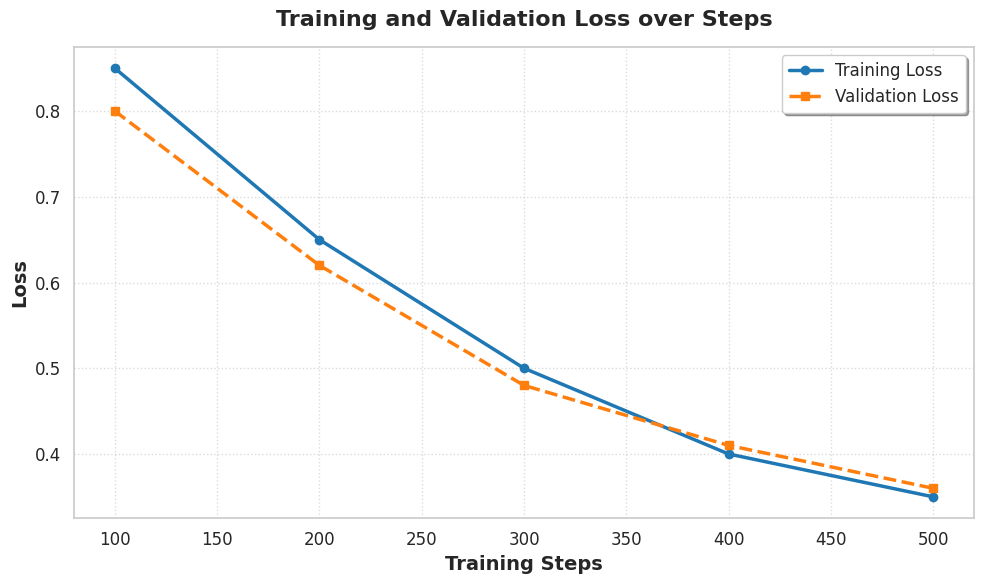

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder to save the high-res images
os.makedirs("thesis_matrices", exist_ok=True)

# ---------------------------------------------------------
# OPTION 1: If you have your Trainer object, extract automatically:
# ---------------------------------------------------------
try:
    log_history = trainer.state.log_history
    steps = []
    train_loss = []
    val_loss = []

    # Extract training loss (recorded at specific steps)
    train_logs = [log for log in log_history if 'loss' in log and 'step' in log]
    # Extract validation loss (recorded at evaluation steps)
    val_logs = [log for log in log_history if 'eval_loss' in log and 'step' in log]

    steps = [log['step'] for log in val_logs]
    val_loss = [log['eval_loss'] for log in val_logs]

    # Match training loss to the evaluation steps for a clean plot
    train_loss = []
    for step in steps:
        # Find the closest training loss recorded before or at this step
        closest_train = next((log['loss'] for log in reversed(train_logs) if log['step'] <= step), None)
        train_loss.append(closest_train)

except NameError:
    print("Trainer object not found. Using manual data entry...")
    # ---------------------------------------------------------
    # OPTION 2: Manually enter the data from your screenshot here
    # ---------------------------------------------------------
    # Look at your data.png screenshot and type the numbers below:
    steps = [100, 200, 300, 400, 500] # Example steps
    train_loss = [0.85, 0.65, 0.50, 0.40, 0.35] # Example train loss
    val_loss = [0.80, 0.62, 0.48, 0.41, 0.36] # Example eval loss

# ==========================================
# Plotting the Publication-Ready Loss Curve
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot lines with distinct styles for academic printing (black & white friendly)
plt.plot(steps, train_loss, label='Training Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=6)
plt.plot(steps, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=6, linestyle='--')

# Styling the graph
plt.title('Training and Validation Loss over Steps', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Steps', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')

# Add grid lines and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)

# Make ticks larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

# Save the high-resolution image for your thesis
save_path = os.path.join("thesis_matrices", "loss_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"📸 Saved Loss Curve image to: {save_path}")

plt.show()